<a href="https://colab.research.google.com/github/MehdiSaraeian/Classification/blob/add-workshop-scenarios/scenarios/02-random-forest/Scenario_2_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 2: Beyond Lines: Making Decisions with Trees and Forests

In this scenario, we'll explore Decision Trees and their more powerful successor, Random Forests. These models can capture non-linear relationships in the data.

## 1. Import Libraries and Prepare Data

First, we'll set up our environment and load the data, just like in Scenario 1. No feature scaling is needed for tree-based models.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- Data Prep ---
column_names = [
    'id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
    'marg_adhesion', 'single_epith_cell_size', 'bare_nuclei',
    'bland_chrom', 'norm_nucleoli', 'mitoses', 'class'
]
df = pd.read_csv('/content/breast-cancer-wisconsin.data', names=column_names)
df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])
df['bare_nuclei'] = df['bare_nuclei'].fillna(df['bare_nuclei'].median())
df.drop('id', axis=1, inplace=True)
df['class'] = df['class'].map({2: 0, 4: 1})
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2. Train a Single Decision Tree

Let's start by training a single Decision Tree to see how it performs.

In [5]:
# HINT: Create an instance of DecisionTreeClassifier and fit it to the training data.

# YOUR CODE HERE
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate the model
y_pred_dt = dt_model.predict(X_test)
print("--- Single Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

--- Single Decision Tree ---
Accuracy: 0.9286
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        92
           1       0.93      0.85      0.89        48

    accuracy                           0.93       140
   macro avg       0.93      0.91      0.92       140
weighted avg       0.93      0.93      0.93       140



## 3. Visualize the Decision Tree

One of the best features of Decision Trees is that we can visualize them to understand the rules they've learned.

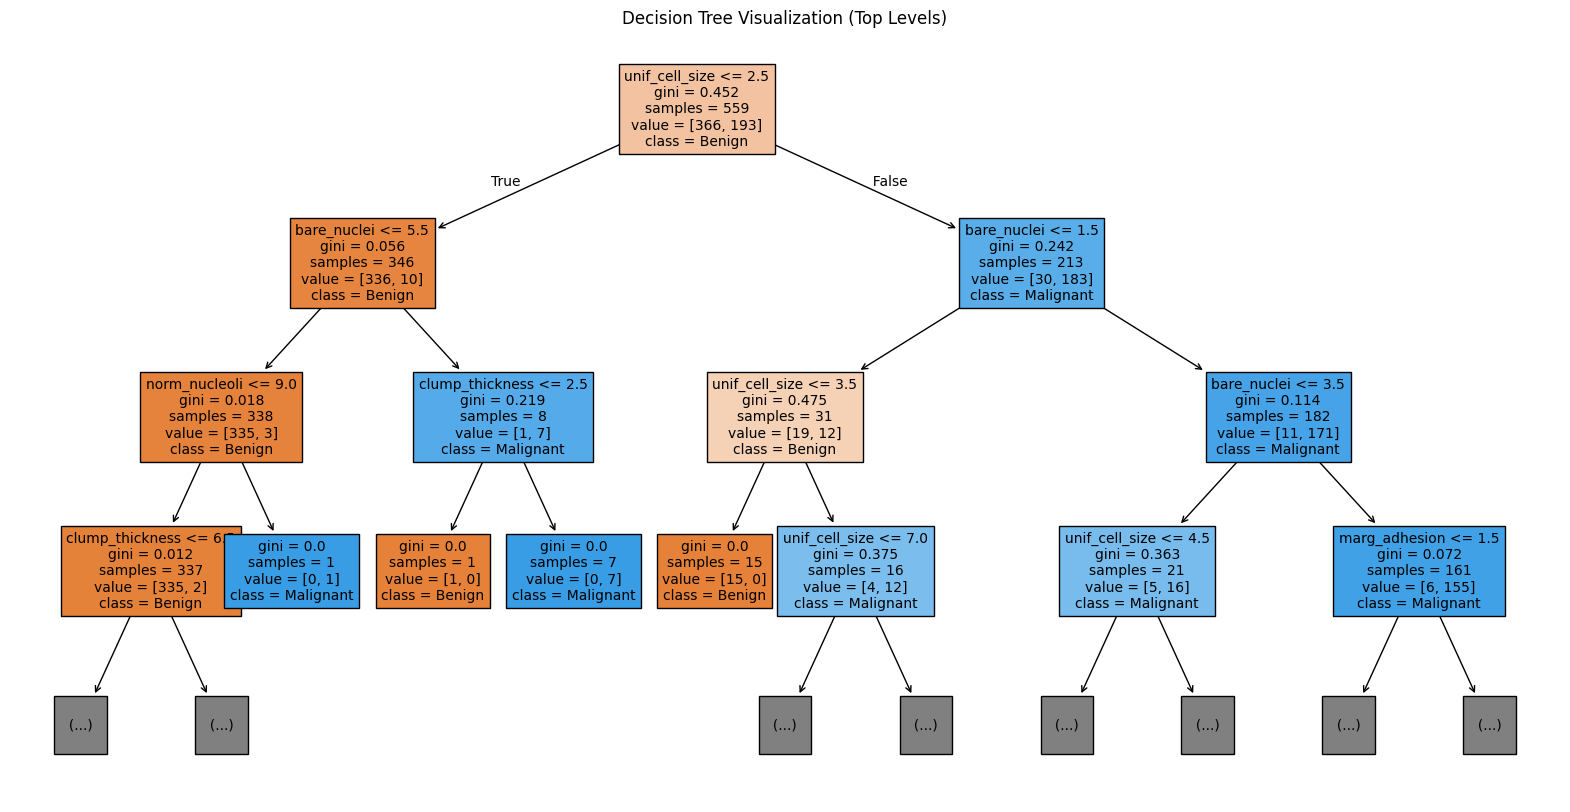

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], max_depth=3, filled=True, fontsize=10)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

## 4. Train a Random Forest Model

A single Decision Tree can easily overfit. A Random Forest builds many trees and aggregates their predictions to produce a more robust model. Let's build one now.

In [7]:
# HINT: Create a RandomForestClassifier. A good starting point is n_estimators=100.
# Fit the model to the training data.

# YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_model.predict(X_test)
print("\n--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
Accuracy: 0.9500
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        92
           1       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



## 5. Analyze Feature Importance

Random Forests can tell us which features were most important for making predictions. This is a powerful tool for understanding our data.

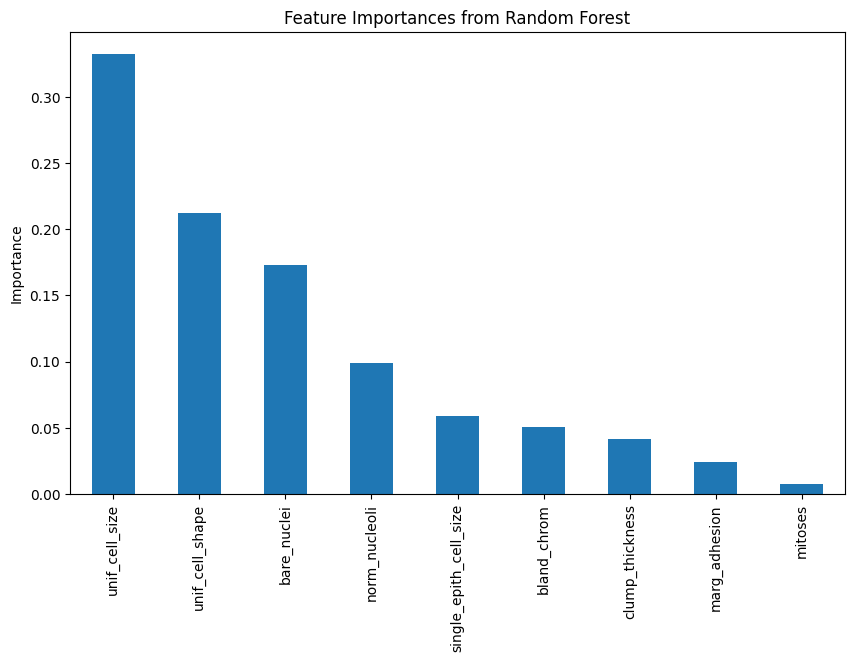


Top 5 most important features:
unif_cell_size            0.332384
unif_cell_shape           0.212634
bare_nuclei               0.173205
norm_nucleoli             0.099276
single_epith_cell_size    0.058808
dtype: float64


In [8]:
# HINT: The feature importances are stored in the `feature_importances_` attribute of the trained model.
# Create a pandas Series to easily view and plot them.

# YOUR CODE HERE
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importances from Random Forest')
plt.ylabel('Importance')
plt.show()

print("\nTop 5 most important features:")
print(importances.head())